# Notebook 01: Isotherm Fitting (Real Data)

This notebook fits multiple adsorption isotherm models to experimental data loaded from a file.


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

from utils_isotherms import (
    MODELS,
    compute_SSE, compute_R2, compute_AIC, compute_BIC,
    compute_EABS, compute_RESID, compute_ARED, compute_MPSED, compute_HYBRID,
    extract_descriptors,
)

In [9]:
def build_fit_config(Ce, q_exp):
    """
    Build data-adaptive initial guesses and bounds for all 13 isotherm models.
    Scales p0 values from the experimental data so fitting converges regardless
    of the concentration / capacity range.
    """
    _Qg  = float(np.max(q_exp)) * 1.5        # generous Qmax starting guess
    _Kg  = 1.0 / float(np.median(Ce))         # affinity scale from data
    _Qhi = float(np.max(q_exp)) * 20          # upper bound for Qmax

    return {
        'Langmuir':         {'p0': [_Qg, _Kg],
                             'bounds': ([0, 0], [_Qhi, np.inf])},
        'Double Langmuir':  {'p0': [_Qg * 0.6, _Kg * 2, _Qg * 0.4, _Kg * 0.3],
                             'bounds': ([0, 0, 0, 0], [_Qhi, np.inf, _Qhi, np.inf])},
        'Freundlich':       {'p0': [max(_Qg * _Kg**0.5, 1e-3), 0.5],
                             'bounds': ([0, 0.05], [np.inf, 2.0])},
        'Sips':             {'p0': [_Qg, _Kg, 0.8],
                             'bounds': ([0, 0, 0.1], [_Qhi, np.inf, 2.0])},
        'Toth':             {'p0': [_Qg, _Kg, 0.8],
                             'bounds': ([0, 0, 0.1], [_Qhi, np.inf, 2.0])},
        'Jovanovic':        {'p0': [_Qg, _Kg],
                             'bounds': ([0, 0], [_Qhi, np.inf])},
        'Temkin':           {'p0': [_Kg, 1.0],
                             'bounds': ([0, 1e-6], [np.inf, np.inf])},
        'UNILAN':           {'p0': [_Qg, _Kg * 5, _Kg / 5],
                             'bounds': ([0, 1e-10, 1e-10], [_Qhi, np.inf, np.inf])},
        'Redlich-Peterson': {'p0': [_Qg * _Kg, _Kg, 0.9],
                             'bounds': ([0, 0, 0.01], [np.inf, np.inf, 1.0])},
        'Koble-Corrigan':   {'p0': [max(_Qg * _Kg**0.5, 1e-3), max(_Kg**0.5, 1e-6), 0.5],
                             'bounds': ([0, 0, 0.05], [np.inf, np.inf, 2.0])},
        'Radke-Prausnitz':  {'p0': [_Qg, _Qg * _Kg, 0.5],
                             'bounds': ([0, 0, 0.01], [np.inf, np.inf, 1.0])},
        'D-R/D-A':          {'p0': [_Qg, 8.0, 2.0],
                             'bounds': ([0, 0.1, 1.0], [_Qhi, 50.0, 6.0])},
        'Hill':             {'p0': [_Qg, 1.0 / _Kg, 1.0],
                             'bounds': ([0, 0, 0.1], [_Qhi, np.inf, 4.0])},
    }

## Load experimental data

Expected columns: `Ce`, `qe`. The loader also accepts `ce`/`qe` (case-insensitive).


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                        DATA FILE CONFIGURATION                               ║
# ║                                                                              ║
# ║  Set DATA_FILE below to the name of your experimental isotherm data file.    ║
# ║  Place the file in the SAME FOLDER as this notebook.                         ║
# ║                                                                              ║
# ║  File requirements:                                                          ║
# ║    - Format  : CSV (.csv) or Excel (.xlsx / .xls)                            ║
# ║    - Columns : Ce  (equilibrium concentration, mg/L)                         ║
# ║                qe  (adsorption capacity, mg/g)                               ║
# ║    - Column names are case-insensitive (Ce, ce, CE all work).                ║
# ║                                                                              ║
# ║  Examples:                                                                   ║
# ║    DATA_FILE = "sample_isotherm_data.csv"          # included sample         ║
# ║    DATA_FILE = "my_experiment.xlsx"                 # your own data          ║
# ║                                                                              ║
# ║  A sample file (sample_isotherm_data.csv) is included for testing.           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

DATA_FILE = "sample_isotherm_data.csv"   # <--- CHANGE THIS to your data file

# ══════════════════════════════════════════════════════════════════════════════
#  Do NOT modify anything below this line unless you know what you are doing.
# ══════════════════════════════════════════════════════════════════════════════

# ── Resolve path relative to this notebook's folder ───────────────────────────
_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_PATH = os.path.join(_NOTEBOOK_DIR, DATA_FILE)

# ── Validate input ────────────────────────────────────────────────────────────
if not DATA_FILE or DATA_FILE.strip() == "":
    raise ValueError(
        "\n\n"
        "  *** ERROR: No data file specified! ***\n\n"
        "  Go to the top of this cell and set DATA_FILE to your file name.\n\n"
        "  Example:\n"
        "      DATA_FILE = 'sample_isotherm_data.csv'\n"
    )

if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError(
        f"\n\n"
        f"  *** ERROR: File not found: '{DATA_FILE}' ***\n\n"
        f"  Looked in: {_NOTEBOOK_DIR}\n\n"
        f"  Place your data file in the same folder as this notebook.\n"
    )

# ── Load data ─────────────────────────────────────────────────────────────────
ext = os.path.splitext(DATA_FILE)[1].lower()
if ext == '.csv':
    df_data = pd.read_csv(DATA_PATH)
elif ext in ('.xlsx', '.xls'):
    df_data = pd.read_excel(DATA_PATH)
else:
    raise ValueError(
        f"\n  Unsupported file format '{ext}'. Use .csv or .xlsx\n"
    )

# Normalise column names (case-insensitive)
col_map = {c.strip().lower(): c for c in df_data.columns}
if 'ce' not in col_map or 'qe' not in col_map:
    raise ValueError(
        f"\n\n"
        f"  *** ERROR: Required columns not found! ***\n\n"
        f"  Your file has columns: {list(df_data.columns)}\n"
        f"  This notebook expects two columns named 'Ce' and 'qe'\n"
        f"  (case-insensitive: Ce, ce, CE, etc. all work).\n"
    )

df_data = df_data.rename(columns={col_map['ce']: 'Ce', col_map['qe']: 'qe'})
df_data = df_data[['Ce', 'qe']].dropna()
df_data = df_data[(df_data['Ce'] > 0) & (df_data['qe'] >= 0)].sort_values('Ce')

if len(df_data) < 4:
    raise ValueError(
        f"\n\n"
        f"  *** ERROR: Not enough valid data points ({len(df_data)})! ***\n\n"
        f"  At least 4 data points are needed for meaningful fitting.\n"
        f"  Check your file for missing or negative values.\n"
    )

Ce = df_data['Ce'].to_numpy(dtype=float)
q_exp = df_data['qe'].to_numpy(dtype=float)

print(f"Loaded {len(df_data)} data points from '{DATA_FILE}'")
print(f"  Ce range : {Ce.min():.4g} -- {Ce.max():.4g} mg/L")
print(f"  qe range : {q_exp.min():.4g} -- {q_exp.max():.4g} mg/g")

Loaded 10 data points from 'sample_isotherm_data.csv'
  Ce range : 0.1 -- 100 mg/L
  qe range : 1.2 -- 49 mg/g


## Fit candidate isotherm models


In [11]:
# All 13 isotherm models from main.tex / SI.tex
model_names = [
    'Langmuir', 'Double Langmuir', 'Freundlich', 'Sips', 'Toth',
    'Jovanovic', 'Temkin', 'UNILAN', 'Redlich-Peterson',
    'Koble-Corrigan', 'Radke-Prausnitz', 'D-R/D-A', 'Hill',
]

# Build data-adaptive initial guesses and bounds
fit_config = build_fit_config(Ce, q_exp)

results = []
n = len(Ce)

for model_name in model_names:
    func, param_names, p = MODELS[model_name]
    cfg = fit_config[model_name]
    try:
        with np.errstate(over='ignore', invalid='ignore', divide='ignore'):
            popt, pcov = curve_fit(
                func, Ce, q_exp,
                p0=cfg['p0'], bounds=cfg['bounds'], maxfev=30000,
            )
            q_pred = func(Ce, *popt)
        sse   = compute_SSE(q_exp, q_pred)
        r2    = compute_R2(q_exp, q_pred)
        aic   = compute_AIC(n, sse, p)
        bic   = compute_BIC(n, sse, p)
        eabs  = compute_EABS(q_exp, q_pred)
        resid = compute_RESID(q_exp, q_pred)
        ared  = compute_ARED(q_exp, q_pred)
        mpsed = compute_MPSED(q_exp, q_pred)
        hybrid = compute_HYBRID(q_exp, q_pred, p)
        results.append({
            'model': model_name, 'params': popt, 'param_names': param_names,
            'n_params': p, 'func': func, 'q_pred': q_pred,
            'SSE': sse, 'R2': r2, 'AIC': aic, 'BIC': bic,
            'EABS': eabs, 'RESID': resid, 'ARED': ared,
            'MPSED': mpsed, 'HYBRID': hybrid,
        })
        print(f"  ✓ {model_name:20s}  R²={r2:.6f}  SSE={sse:.4f}")
    except Exception as e:
        results.append({
            'model': model_name, 'params': None, 'param_names': param_names,
            'n_params': p, 'func': func, 'q_pred': None,
            'SSE': np.nan, 'R2': np.nan, 'AIC': np.nan, 'BIC': np.nan,
            'EABS': np.nan, 'RESID': np.nan, 'ARED': np.nan,
            'MPSED': np.nan, 'HYBRID': np.nan, 'error': str(e),
        })
        print(f"  ✗ {model_name:20s}  FAILED — {e}")

# Summary table sorted by AIC
summary = pd.DataFrame([{
    'Model': r['model'], 'p': r['n_params'],
    'SSE': r['SSE'], 'R²': r['R2'],
    'AIC': r['AIC'], 'BIC': r['BIC'],
    'EABS': r['EABS'], 'RESID': r['RESID'],
    'ARED': r['ARED'], 'MPSED': r['MPSED'], 'HYBRID': r['HYBRID'],
} for r in results])
summary.sort_values('AIC', inplace=True)
print(f"\n{'='*70}")
print(f"  {len([r for r in results if r['params'] is not None])}/{len(model_names)} models converged")
print(f"{'='*70}")
summary

  ✓ Langmuir              R²=0.992548  SSE=20.8400
  ✓ Double Langmuir       R²=0.999977  SSE=0.0631
  ✓ Freundlich            R²=0.964970  SSE=97.9604
  ✓ Sips                  R²=0.999722  SSE=0.7779
  ✓ Toth                  R²=0.999332  SSE=1.8686
  ✓ Jovanovic             R²=0.974422  SSE=71.5276
  ✓ Temkin                R²=0.948010  SSE=145.3868
  ✓ UNILAN                R²=0.998902  SSE=3.0703
  ✓ Redlich-Peterson      R²=0.998299  SSE=4.7556
  ✓ Koble-Corrigan        R²=0.999722  SSE=0.7779
  ✓ Radke-Prausnitz       R²=0.998299  SSE=4.7556
  ✓ D-R/D-A               R²=0.955783  SSE=123.6491
  ✓ Hill                  R²=0.999722  SSE=0.7779

  13/13 models converged


,Model,p,SSE,R²,AIC,BIC,EABS,RESID,ARED,MPSED,HYBRID
1,Double Langmuir,4,0.063104,0.999977,-42.655564,-41.445223,0.619610,0.061961,1.320719,0.003290,0.200541
12,Hill,3,0.777922,0.999722,-19.537142,-18.629387,2.482317,0.248232,4.123797,0.023670,1.615531
3,Sips,3,0.777922,0.999722,-19.537142,-18.629387,2.482317,0.248232,4.123797,0.023670,1.615531
9,Koble-Corrigan,3,0.777922,0.999722,-19.537142,-18.629387,2.482317,0.248232,4.123797,0.023670,1.615531
4,Toth,3,1.868574,0.999332,-10.774098,-9.866342,3.950442,0.395044,4.160791,0.077352,2.108173
7,UNILAN,3,3.070256,0.998902,-5.808240,-4.900485,5.181446,0.518145,7.964008,0.120974,5.825948
10,Radke-Prausnitz,3,4.755573,0.998299,-1.432679,-0.524923,6.402862,0.640286,8.847913,0.157570,7.437133
8,Redlich-Peterson,3,4.755573,0.998299,-1.432679,-0.524923,6.402862,0.640286,8.847913,0.157570,7.437132
0,Langmuir,2,20.840003,0.992548,11.342893,11.948063,12.428826,1.242883,19.968800,1.260370,35.845518
5,Jovanovic,2,71.527563,0.974422,23.674978,24.280148,24.063311,2.406331,30.188005,5.955265,87.756945


## Plot experimental data and top model fits


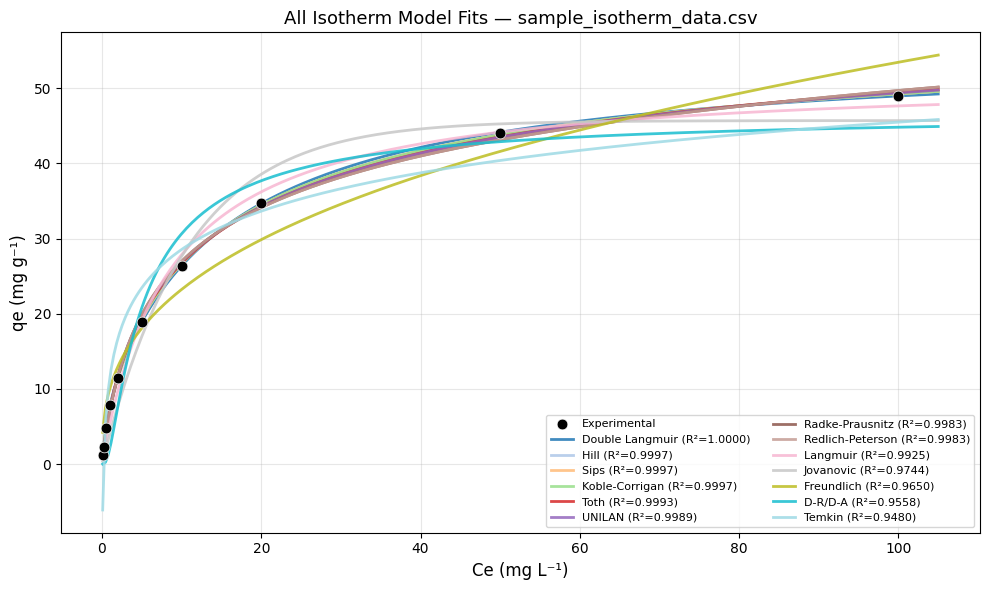

In [12]:
# Plot all converged model fits
fig, ax = plt.subplots(figsize=(10, 6))

# Experimental data
ax.scatter(Ce, q_exp, color='black', label='Experimental', s=60,
           zorder=15, edgecolors='white', linewidths=0.5)

# Smooth evaluation grid (slightly beyond data range)
Ce_fine = np.linspace(Ce.min() * 0.9, Ce.max() * 1.05, 300)

# Sort by SSE (best first) for consistent legend ordering
ok_results = sorted([r for r in results if r['q_pred'] is not None],
                    key=lambda x: x['SSE'])
n_ok = len(ok_results)
cmap = plt.cm.tab20

for i, r in enumerate(ok_results):
    try:
        with np.errstate(over='ignore', invalid='ignore', divide='ignore'):
            q_fine = r['func'](Ce_fine, *r['params'])
        ax.plot(Ce_fine, q_fine,
                color=cmap(i / max(n_ok - 1, 1)),
                linewidth=2, alpha=0.85,
                label=f"{r['model']} (R²={r['R2']:.4f})")
    except Exception:
        pass

ax.set_xlabel('Ce (mg L⁻¹)', fontsize=12)
ax.set_ylabel('qe (mg g⁻¹)', fontsize=12)
ax.set_title(f'All Isotherm Model Fits — {os.path.basename(DATA_FILE)}', fontsize=13)
ax.legend(fontsize=8, loc='best', ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Fitted parameters for each converged model

In [14]:
# Display fitted parameters for each model
rows = []
for r in results:
    if r['params'] is None:
        rows.append({'Model': r['model'], 'Status': 'FAILED'})
        continue
    row = {'Model': r['model'], 'Status': 'OK'}
    for name, val in zip(r['param_names'], r['params']):
        row[name] = val
    rows.append(row)

df_params = pd.DataFrame(rows).set_index('Model')
df_params

,Status,Qmax,KL,Q1,K1,Q2,K2,KF,1/n,KS,...,beta,A,B,a,r,p,Ea,nDA,KD,nH
Model,,,,,,,,,,,,,,,,,,,,,
Langmuir,OK,51.738400,0.116667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Double Langmuir,OK,NaN,NaN,8.801999,1.249546,46.479921,0.064564,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Freundlich,OK,NaN,NaN,NaN,NaN,NaN,NaN,10.09846,0.361897,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sips,OK,60.255604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073379,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Toth,OK,67.125584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Jovanovic,OK,45.701113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temkin,OK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UNILAN,OK,61.022581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Redlich-Peterson,OK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.855068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Universal descriptor extraction

Extract {Q_max, ln K*_aff, E_ads, σ_E} fingerprint from each converged model.

In [15]:
# Extract universal descriptors for each converged model
desc_rows = []
for r in results:
    if r['params'] is None:
        continue
    # Build param dict for extract_descriptors
    param_dict = dict(zip(r['param_names'], r['params']))
    try:
        d = extract_descriptors(r['model'], param_dict)
        desc_rows.append({
            'Model':       r['model'],
            'Q_max':       d['Qmax'],
            'ln_Kaff':     np.log(d['Kaff_star']) if d['Kaff_star'] > 0 else np.nan,
            'E_ads (kJ/mol)': d['Eads'],
            'σ_E (kJ/mol)':   d['sigma_E'],
        })
    except Exception as e:
        desc_rows.append({
            'Model': r['model'], 'Q_max': np.nan,
            'ln_Kaff': np.nan, 'E_ads (kJ/mol)': np.nan,
            'σ_E (kJ/mol)': np.nan,
        })

df_desc = pd.DataFrame(desc_rows).set_index('Model')
print("Universal descriptors (C⁰ = 1 mg/L, T = 298 K)")
df_desc

Universal descriptors (C⁰ = 1 mg/L, T = 298 K)


,Q_max,ln_Kaff,E_ads (kJ/mol),σ_E (kJ/mol)
Model,,,,
Langmuir,51.738400,-2.148430,-5.322891,0.000000
Double Langmuir,55.281920,-1.258661,-3.118423,7.340756
Freundlich,NaN,1.295986,3.210899,inf
Sips,60.255604,-3.472297,-8.602866,3.380586
Toth,67.125584,-1.593658,-3.948402,8.043253
Jovanovic,45.701113,-2.377080,-5.889386,3.177610
Temkin,NaN,1.577990,3.909584,NaN
UNILAN,61.022581,-2.644347,-6.551559,3.381864
Redlich-Peterson,26.888786,-1.031094,-2.554610,NaN
